# SPIN — master figure set

Every figure is built from **one file**, `master_metrics.csv` (1,424 tidy rows), and nothing else.
Style, palette and `rcParams` are lifted verbatim from `thesis_viz/make_figures.py` so these
figures sit next to the existing ones without a visual seam.

**Contents**

| # | Figure | What it settles |
|---|---|---|
| 1 | Fairness–privacy plane | the trade-off is model-specific, not method-specific |
| 2 | Iteration dose–response | three models improve with `n`, one collapses |
| 3 | Soft-α dose–response | benefit and cost both decay — cost faster |
| 4 | Cost–benefit Pareto | where the method stops paying for itself |
| 5 | HSIC vs behaviour | representational decoupling does **not** predict safe-rate |
| 6 | Per-round selector dynamics | the honest replacement for the Jaccard-churn figure |
| 7 | Clinical vs general transfer | same model, opposite privacy sign |
| 8 | Clinical per-benchmark | the pooled clinical gain is one subset |
| 9 | σ-robustness | 76/80 configs sign-stable across bandwidth |
| 10 | Budget-matched arms | it isn't just "more weights removed" |
| 11 | Coupling specificity | the coupled set is 849,842× chance |
| 12 | MMLU vs perplexity | two capability measures, one story |
| 13 | Compute cost | what iteration actually costs |
| 14 | Calibration-sample ablation | not an artefact of the sample source |
| 15 | Clinical privacy correction | the empties-as-safe sensitivity |

Figures are written to `fig_out_master/` as both `.pdf` (vector, for the thesis) and `.png`.

## 0 · Setup — palette, loader, unit conventions

The palette is the `thesis_viz` one: rose / periwinkle / teal / marigold / cornflower.
It passes a colour-vision-deficiency check (worst adjacent pair ΔE 9.6 protan), but teal and
marigold fall under 3:1 contrast against the near-white panel, so **every series is either
direct-labelled or in a legend** — identity is never carried by colour alone.

In [1]:
import os, json, itertools, warnings
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- style (verbatim from thesis_viz/make_figures.py) ----------
CAT = ['#D06A88', '#7B6FC7', '#2BA88C', '#E0913D', '#4E86C7']  # rose periwinkle teal marigold cornflower
MODc = {'gemma-2-2b-it': '#D06A88', 'Llama-3.2-3B-Instruct': '#7B6FC7',
        'Qwen2.5-3B-Instruct': '#2BA88C', 'Qwen2-7B-Instruct': '#E0913D'}
MODn = {'gemma-2-2b-it': 'gemma-2-2B', 'Llama-3.2-3B-Instruct': 'Llama-3.2-3B',
        'Qwen2.5-3B-Instruct': 'Qwen2.5-3B', 'Qwen2-7B-Instruct': 'Qwen2-7B'}
ARMc = {'iter': '#D06A88', 'global': '#4E86C7', 'percat': '#2BA88C', 'soft': '#E0913D'}
ARMn = {'iter': 'iterative', 'global': 'global top-k', 'percat': 'per-category', 'soft': 'soft (α)'}
ARMm = {'iter': 'o', 'global': 's', 'percat': '^', 'soft': 'D'}   # shape = second channel for identity
AXc  = {'fairness': '#2BA88C', 'privacy': '#7B6FC7'}

def tint(h, f=0.55):
    r, g, b = int(h[1:3], 16), int(h[3:5], 16), int(h[5:7], 16)
    return f'#{int(r+(255-r)*f):02X}{int(g+(255-g)*f):02X}{int(b+(255-b)*f):02X}'

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9.5, 'axes.edgecolor': '#999', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ECECEC', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': '#FCFCFB',
    'axes.titlesize': 10, 'axes.titleweight': 'bold',
    'legend.frameon': False, 'legend.fontsize': 8,
    'axes.axisbelow': True,          # grid behind the marks, never through a bar
    'figure.dpi': 110,
})

POC  = ['gemma-2-2b-it', 'Llama-3.2-3B-Instruct', 'Qwen2.5-3B-Instruct']
ALL4 = POC + ['Qwen2-7B-Instruct']

def title(ax, t):
    ax.set_title(t, loc='left')

def zeroline(ax, horizontal=True, v=0):
    (ax.axhline if horizontal else ax.axvline)(v, color='#BBB', lw=0.8, zorder=0)

def label_ends(ax, items, dx=5, fontsize=7, min_gap_frac=0.055):
    """Direct-label line ends, pushed apart so they never overlap.

    items: list of (x, y, text, colour). Labels are nudged vertically until each
    is at least `min_gap_frac` of the axis height from its neighbour.
    """
    if not items:
        return
    items = sorted(items, key=lambda t: t[1])
    y0, y1 = ax.get_ylim()
    gap = abs(y1 - y0) * min_gap_frac
    ys = [it[1] for it in items]
    for i in range(1, len(ys)):                       # push up
        if ys[i] - ys[i-1] < gap:
            ys[i] = ys[i-1] + gap
    for (x, _, txt, c), yy in zip(items, ys):
        ax.annotate(txt, (x, yy), fontsize=fontsize, color=c,
                    xytext=(dx, -2), textcoords='offset points',
                    annotation_clip=False)

OUT = 'fig_out_master'
os.makedirs(OUT, exist_ok=True)
_index = []

def save(fig, name):
    """Write pdf + png and register in the figure index."""
    fig.savefig(f'{OUT}/{name}.pdf', bbox_inches='tight')
    fig.savefig(f'{OUT}/{name}.png', dpi=160, bbox_inches='tight')
    _index.append(name)
    return fig

In [2]:
# ---------- load ----------
CANDIDATES = ['master_metrics.csv', '../master_metrics.csv', '../../master_metrics.csv',
              os.path.expanduser('~/mnt/SPIN-main/thesis_master_data/master_metrics.csv')]
CSV = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert CSV, f'master_metrics.csv not found; looked in {CANDIDATES}'
M = pd.read_csv(CSV)
print(f'loaded {CSV}  ->  {M.shape[0]} rows x {M.shape[1]} cols')

def g(df=None, **k):
    """Filter helper. g(metric='hsic', model='...'); pass None to match NaN."""
    d = M.copy() if df is None else df.copy()
    for c, v in k.items():
        if v is None:
            d = d[d[c].isna()]
        elif isinstance(v, (list, tuple, set)):
            d = d[d[c].isin(list(v))]
        else:
            d = d[d[c] == v]
    return d

loaded master_metrics.csv  ->  1424 rows x 21 cols


### 0.1 · Unit conventions — read this before touching an axis

The `delta` column is **not** in one unit. Mixing them silently is the single easiest way to
produce a wrong figure from this file:

| metric | `delta` unit | conversion used below |
|---|---|---|
| `safe_rate` | fraction (−0.283 … +0.154) | `× 100` → percentage points |
| `safe_rate_priv_corrected*` | **already percentage points** | none |
| `hsic`, `hsic_norm`, `cka`, `hsic_subset` | **% change** vs baseline | none |
| `perplexity` | **% change** vs baseline | none |
| `mmlu` | fraction | `× 100` → percentage points |
| `coupled_zeroed`, `sparsity`, round metrics | raw counts / seconds | none |

Everything below routes through `pts()` / `pct()` so the unit is declared at the call site.

In [3]:
def pts(series):
    """safe_rate / mmlu fraction -> percentage points."""
    return series.astype(float) * 100

def pct(series):
    """already a % change (hsic, perplexity) -> passthrough, named for the call site."""
    return series.astype(float)

### 0.2 · Data audit — the five traps in this file

Run this once. Each check corresponds to a way the table will quietly mislead you.

In [4]:
print('=' * 74)
print('AUDIT')
print('=' * 74)

# 1 — duplicate keys
KEY = ['variant','model','domain','arm','param_type','param_value','axis','subset','sigma','metric']
dups = M[M.duplicated(subset=KEY, keep=False)]
print(f'1. duplicate keys                 : {len(dups)} rows'
      f"  ({', '.join(sorted(set(dups.metric))) or 'none'})")

# 2 — clinical perplexity has TWO baselines (wikitext 7.60 and med 16.12).
#     Joining perplexity without `subset` duplicates every clinical row.
ppl_sub = g(metric='perplexity').groupby('domain').subset.unique().to_dict()
print(f'2. perplexity subsets by domain   : {ppl_sub}')
print('   -> always join clinical perplexity on subset, or every clinical row doubles')

# 3 — the per-round (CR) table holds FIVE runs, not four: Qwen2-7B appears in
#     general *and* clinical. Grouping by model alone averages two different runs.
cr_runs = g(source='CR')[['model','domain']].drop_duplicates()
print(f'3. per-round runs                 : {len(cr_runs)} '
      f'({cr_runs.domain.value_counts().to_dict()})')

# 4 — bootstrap CIs cover only part of the safe_rate rows
sr = g(metric='safe_rate')
print(f'4. safe_rate rows with CI         : {sr.ci_lo.notna().sum()} / {len(sr)}'
      '  -> error bars are not available on every panel')

# 5 — n=1 exists only for the `iter` arm. Correct by construction: at n=1 iterSPIN *is*
#     one-shot top-k, so global/percat are degenerate. Not missing data — do not impute.
n1 = g(metric='safe_rate', param_value=1.0).arm.unique()
print(f'5. arms present at n=1            : {list(n1)}  -> degenerate for global/percat, by design')

# sanity: delta really is value - baseline for safe_rate (to stored precision)
resid = ((sr.value - sr.baseline) - sr.delta).abs()
print(f'\nsanity: max |(value-baseline) - delta| over safe_rate = {resid.max():.2e} (rounding only)')

AUDIT
1. duplicate keys                 : 2 rows  (sparsity)
2. perplexity subsets by domain   : {'clinical': <StringArray>
['wikitext', 'med']
Length: 2, dtype: str, 'general': <StringArray>
['wikitext']
Length: 1, dtype: str}
   -> always join clinical perplexity on subset, or every clinical row doubles
3. per-round runs                 : 5 ({'general': 4, 'clinical': 1})
4. safe_rate rows with CI         : 96 / 198  -> error bars are not available on every panel
5. arms present at n=1            : ['soft', 'iter']  -> degenerate for global/percat, by design

sanity: max |(value-baseline) - delta| over safe_rate = 1.00e-04 (rounding only)


### 0.3 · The config-level table

Most figures need several metric families on one row. `runs` is the wide, one-row-per-config
join — built once, with the clinical-perplexity trap handled explicitly and a duplication assert
so it can never silently double.

In [5]:
KEYC = ['variant','model','domain','arm','param_value']

def _wide(metric, col, name, **extra):
    d = g(metric=metric, **extra)
    return d.set_index(KEYC)[[col]].rename(columns={col: name})

sr_pool = g(metric='safe_rate', subset='pooled')
fair = sr_pool[sr_pool.axis == 'fairness'].set_index(KEYC)[['delta','p','baseline','value']] \
        .rename(columns={'delta':'d_fair','p':'p_fair','baseline':'b_fair','value':'v_fair'})
priv = sr_pool[sr_pool.axis == 'privacy'].set_index(KEYC)[['delta','p','baseline','value']] \
        .rename(columns={'delta':'d_priv','p':'p_priv','baseline':'b_priv','value':'v_priv'})

# perplexity: wikitext only, so the clinical `med` row cannot duplicate the join
ppl  = _wide('perplexity', 'delta', 'd_ppl_pct', subset='wikitext')
mmlu = _wide('mmlu', 'delta', 'd_mmlu')
zero = g(metric='coupled_zeroed').groupby(KEYC).value.first().rename('zeroed')

hs = (g(metric='hsic').pivot_table(index=KEYC, columns='sigma', values='delta')
        .rename(columns={50.0:'d_hsic_s50', 100.0:'d_hsic_s100',
                         200.0:'d_hsic_s200', 400.0:'d_hsic_s400'}))
hs['d_hsic_mean'] = hs[['d_hsic_s50','d_hsic_s100','d_hsic_s200','d_hsic_s400']].mean(axis=1)

runs = (fair.join(priv, how='outer').join(ppl, how='outer').join(mmlu, how='outer')
            .join(zero, how='outer').join(hs, how='outer').reset_index())

assert not runs.duplicated(subset=KEYC).any(), 'runs duplicated — check the perplexity join'

runs['net_pts']  = pts(runs.d_fair) + pts(runs.d_priv)
runs['eff']      = runs.net_pts / runs.d_ppl_pct.replace(0, np.nan)   # pts per 1% ppl
runs['mdl']      = runs.model.map(MODn).fillna(runs.model)
runs['sig_both'] = (runs.p_fair < .05) & (runs.p_priv < .05)

print(f'{len(runs)} configs · {runs.model.nunique()} model labels · '
      f'{runs.arm.nunique()} arms · {runs.domain.nunique()} domains')
runs.head(3)

95 configs · 6 model labels · 5 arms · 2 domains


,variant,model,domain,arm,param_value,d_fair,p_fair,b_fair,v_fair,d_priv,...,zeroed,d_hsic_s50,d_hsic_s100,d_hsic_s200,d_hsic_s400,d_hsic_mean,net_pts,eff,mdl,sig_both
0,baseline,Qwen2-7B (author-sample),general,spin,NaN,0.060500,2.857066e-11,0.747300,0.807900,0.076100,...,NaN,NaN,NaN,NaN,NaN,NaN,13.660000,7.286111,Qwen2-7B (author-sample),True
1,baseline,Qwen2-7B (python-sample),general,spin,NaN,0.055400,3.898099e-10,0.747300,0.802800,0.068500,...,NaN,NaN,NaN,NaN,NaN,NaN,12.390000,4.224200,Qwen2-7B (python-sample),True
2,baseline,Qwen2-7B-Instruct,clinical,spin,NaN,0.008475,7.537842e-03,0.978814,0.987288,-0.024353,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.587854,-1.080026,Qwen2-7B,False


---
## Figure 1 · The fairness–privacy plane

**Claim it supports:** the trade-off is a property of the *model*, not of the method.

Each point is one run configuration; position is the paired safe-rate change on the two axes,
marker shape is the arm, size is the number of weights zeroed, and a dark ring marks configs
where *both* McNemar tests clear p<0.05. Qwen2-7B sits in the upper-right for every arm;
Qwen2.5-3B is pinned to the lower-right — fairness bought with privacy, at a ruinous rate.

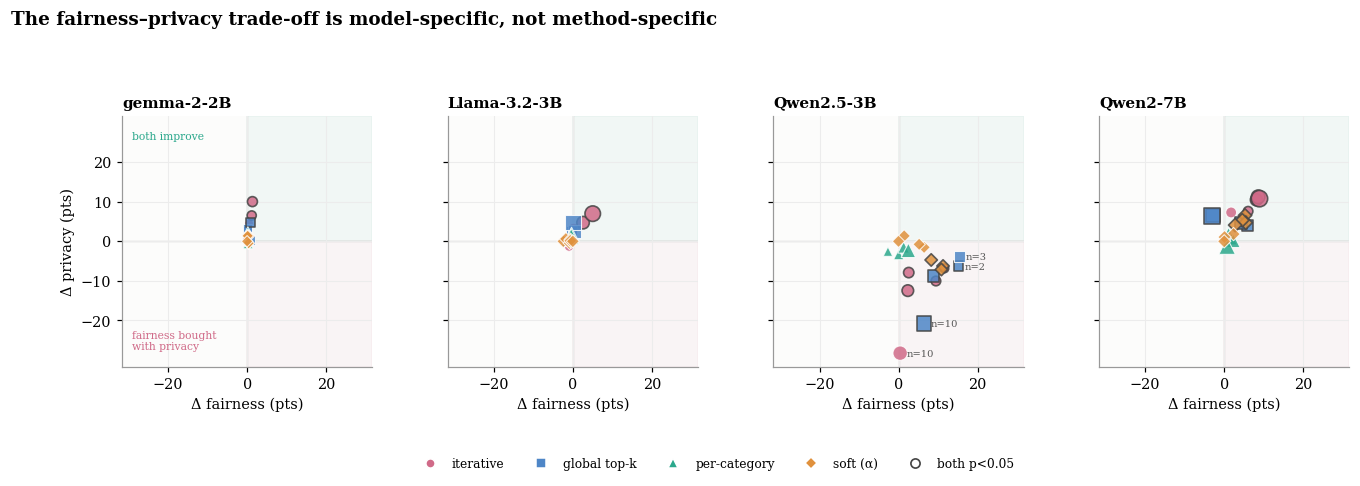

In [6]:
def fig1():
    d = runs[(runs.domain == 'general') & runs.model.isin(ALL4) & runs.d_fair.notna()]
    fig, axs = plt.subplots(1, 4, figsize=(14.4, 4.0), sharex=True, sharey=True)
    # one shared scale across panels — the spread itself is the finding
    lim = np.nanmax(np.abs(np.r_[pts(d.d_fair), pts(d.d_priv)])) * 1.12
    for ax, m in zip(axs, ALL4):
        dm = d[d.model == m]
        ax.add_patch(plt.Rectangle((0, 0), lim, lim, color='#2BA88C', alpha=.05, zorder=0))
        ax.add_patch(plt.Rectangle((0, -lim), lim, lim, color='#D06A88', alpha=.05, zorder=0))
        zeroline(ax); zeroline(ax, horizontal=False)
        for arm in ['iter', 'global', 'percat', 'soft']:
            da = dm[dm.arm == arm]
            if da.empty:
                continue
            s = 26 + 90 * (da.zeroed.fillna(da.zeroed.min()) / max(d.zeroed.max(), 1))
            ax.scatter(pts(da.d_fair), pts(da.d_priv), s=s, marker=ARMm[arm],
                       facecolor=ARMc[arm], alpha=.85,
                       edgecolor=np.where(da.sig_both, '#444', 'white'),
                       linewidth=np.where(da.sig_both, 1.1, .7), zorder=3)
        # direct labels on the extremes (contrast relief: identity never colour-alone)
        for _, r in dm.iterrows():
            extreme = (abs(pts(pd.Series([r.d_priv]))).iloc[0] > 15) or \
                      (abs(pts(pd.Series([r.d_fair]))).iloc[0] > 12)
            if extreme:
                lab = f"{'n' if r.arm != 'soft' else 'α'}={r.param_value:g}"
                ax.annotate(lab, (pts(pd.Series([r.d_fair])).iloc[0],
                                  pts(pd.Series([r.d_priv])).iloc[0]),
                            fontsize=6.5, xytext=(4, -2), textcoords='offset points',
                            color='#555')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal', adjustable='box')
        title(ax, MODn[m]); ax.set_xlabel('Δ fairness (pts)')
        ax.set_xticks([-20, 0, 20]); ax.set_yticks([-20, -10, 0, 10, 20])
    axs[0].set_ylabel('Δ privacy (pts)')
    axs[0].text(.04, .94, 'both improve', transform=axs[0].transAxes, fontsize=7,
                color='#2BA88C', va='top')
    axs[0].text(.04, .06, 'fairness bought\nwith privacy', transform=axs[0].transAxes,
                fontsize=7, color='#D06A88', va='bottom')
    handles = [Line2D([], [], color=ARMc[a], marker=ARMm[a], ls='', mec='white',
                      label=ARMn[a]) for a in ['iter','global','percat','soft']]
    handles += [Line2D([], [], color='w', marker='o', mec='#444', mew=1.1, ls='',
                       label='both p<0.05')]
    fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
               bbox_to_anchor=(.5, -.09))
    fig.suptitle('The fairness–privacy trade-off is model-specific, not method-specific',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.80, wspace=.30)
    return fig

save(fig1(), 'F01_fairness_privacy_plane');

In [7]:
# table view (required relief for the low-contrast hues, and useful on its own)
(runs[(runs.domain == 'general') & runs.model.isin(ALL4)]
   .assign(**{'Δfair (pts)': lambda d: pts(d.d_fair).round(2),
              'Δpriv (pts)': lambda d: pts(d.d_priv).round(2)})
   .pivot_table(index=['mdl','arm'], columns='param_value',
                values='Δpriv (pts)')
   .round(2))

param_value          0.0   0.1   0.3   0.5   0.7   0.9   1.0    2.0    3.0   \
mdl          arm                                                              
Llama-3.2-3B global   NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.00   2.59   
             iter     NaN   NaN   NaN   NaN   NaN   NaN -1.37   0.15   3.20   
             percat   NaN   NaN   NaN   NaN   NaN   NaN   NaN   1.37   0.76   
             soft    0.00  0.61  0.46 -0.46 -0.15  0.15  0.00    NaN    NaN   
Qwen2-7B     global   NaN   NaN   NaN   NaN   NaN   NaN   NaN   3.96   4.57   
             iter     NaN   NaN   NaN   NaN   NaN   NaN  7.61   7.31  10.50   
             percat   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.13   0.61   
             soft    6.54  4.72  5.33  4.11  1.83  1.07  0.00    NaN    NaN   
Qwen2.5-3B   global   NaN   NaN   NaN   NaN   NaN   NaN   NaN  -6.24  -3.81   
             iter     NaN   NaN   NaN   NaN   NaN   NaN -6.85 -10.05  -7.91   
             percat   NaN   NaN   NaN   NaN   NaN   NaN   NaN  -2.59  -3.35   
             soft   -6.24 -7.15 -4.72 -1.52 -0.76  1.37  0.00    NaN    NaN   
gemma-2-2B   global   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.74   3.20   
             iter     NaN   NaN   NaN   NaN   NaN   NaN  0.76  -0.15   4.57   
             percat   NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.46   2.59   
             soft    1.52  1.37 -0.61  1.52  1.37 -0.46  0.00    NaN    NaN   

param_value           5.0    10.0  
mdl          arm                   
Llama-3.2-3B global   2.44   4.72  
             iter     4.72   7.00  
             percat   1.98   1.22  
             soft      NaN    NaN  
Qwen2-7B     global   6.54   6.39  
             iter    11.26  10.81  
             percat   0.15  -1.22  
             soft      NaN    NaN  
Qwen2.5-3B   global  -8.83 -20.85  
             iter   -12.48 -28.31  
             percat  -1.52  -2.28  
             soft      NaN    NaN  
gemma-2-2B   global   4.87   0.46  
             iter     6.54  10.05  
             percat  -0.61  -0.61  
             soft      NaN    NaN

---
## Figure 2 · Iteration dose–response

**Claim it supports:** iteration has a per-model sign.

Qwen2-7B climbs on both axes (+6.0 → +8.9 fairness, +7.6 → +10.8 privacy). Qwen2.5-3B's
fairness gain decays to nothing (+11.6 → +0.4, n.s. at n=10) while privacy collapses to
**−28.3 pts**. The budget-matched controls stay flat throughout, which is what makes the
`iter` line's behaviour attributable to iteration rather than to budget.

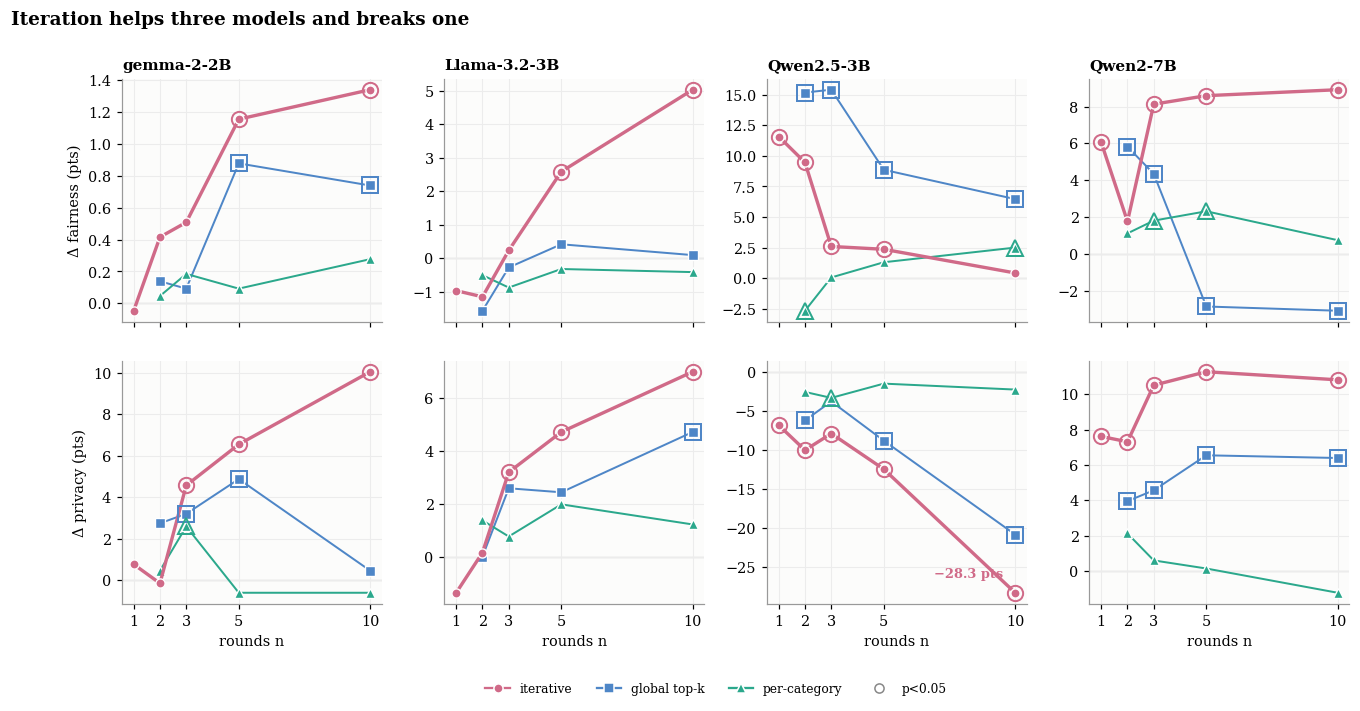

In [8]:
def fig2():
    fig, axs = plt.subplots(2, 4, figsize=(14.4, 6.2), sharex=True)
    for ci, m in enumerate(ALL4):
        for ri, axis in enumerate(['fairness', 'privacy']):
            ax = axs[ri, ci]; zeroline(ax)
            for arm in ['iter', 'global', 'percat']:
                d = g(metric='safe_rate', model=m, domain='general', arm=arm,
                      axis=axis, subset='pooled').sort_values('param_value')
                if d.empty:
                    continue
                lw = 2.2 if arm == 'iter' else 1.3
                ax.plot(d.param_value, pts(d.delta), '-', marker=ARMm[arm],
                        color=ARMc[arm], ms=6, mec='white', mew=.9, lw=lw,
                        label=ARMn[arm], zorder=3 if arm == 'iter' else 2)
                sig = d[d.p < .05]
                ax.plot(sig.param_value, pts(sig.delta), ARMm[arm], ms=10, mfc='none',
                        mec=ARMc[arm], mew=1.3, ls='', zorder=4)
            if ri == 0:
                title(ax, MODn[m])
            if ci == 0:
                ax.set_ylabel(f'Δ {axis} (pts)')
            if ri == 1:
                ax.set_xlabel('rounds n')
            ax.set_xticks([1, 2, 3, 5, 10])
    # direct label on the collapsing line
    ax = axs[1, ALL4.index('Qwen2.5-3B-Instruct')]
    ax.annotate('−28.3 pts', (10, -28.3), fontsize=8.5, color=ARMc['iter'], weight='bold',
                ha='right', xytext=(-8, 10), textcoords='offset points')
    handles = [Line2D([], [], color=ARMc[a], marker=ARMm[a], mec='white', label=ARMn[a])
               for a in ['iter','global','percat']]
    handles += [Line2D([], [], color='#888', marker='o', mfc='none', ls='', label='p<0.05')]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8, bbox_to_anchor=(.5, -.04))
    fig.suptitle('Iteration helps three models and breaks one',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.88, hspace=.16, wspace=.24)
    return fig

save(fig2(), 'F02_iteration_dose_response');

---
## Figure 3 · Soft-α dose–response — benefit and cost, on separate axes

**Claim it supports:** the right operating point is *not* α=0.

Two stacked rows rather than a twin y-axis (two scales on one frame is the classic way to make
a trade-off look like whatever you want). Top: safe-rate change. Bottom: the perplexity bill.
α=1 is the null edit and is pinned at zero by construction, which makes it a useful anchor.
The efficiency table underneath is where the argument actually lands.

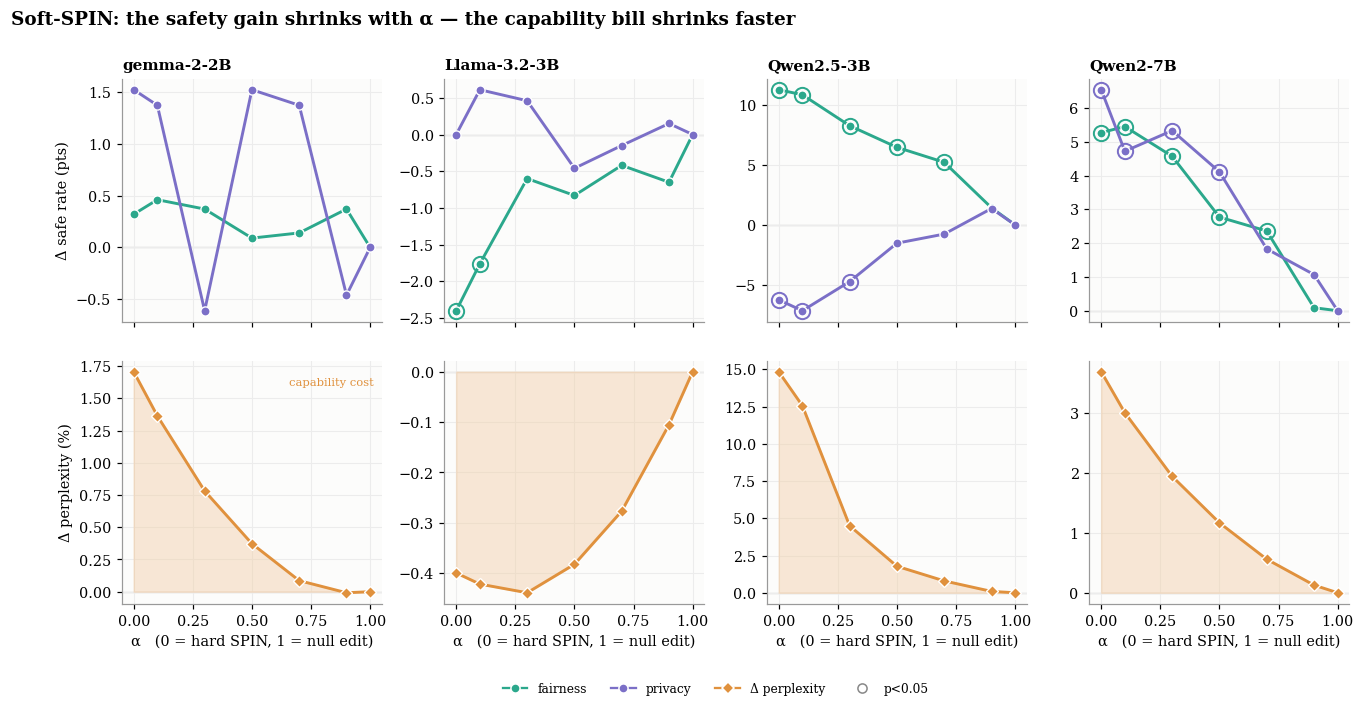

In [9]:
def fig3():
    fig, axs = plt.subplots(2, 4, figsize=(14.4, 6.2), sharex=True)
    for ci, m in enumerate(ALL4):
        ax = axs[0, ci]; zeroline(ax)
        for axis in ['fairness', 'privacy']:
            d = g(metric='safe_rate', model=m, domain='general', arm='soft',
                  axis=axis, subset='pooled').sort_values('param_value')
            ax.plot(d.param_value, pts(d.delta), '-o', color=AXc[axis], ms=6,
                    mec='white', mew=.9, lw=1.9, label=axis)
            sig = d[d.p < .05]
            ax.plot(sig.param_value, pts(sig.delta), 'o', ms=10, mfc='none',
                    mec=AXc[axis], mew=1.3, ls='')
        title(ax, MODn[m])
        if ci == 0:
            ax.set_ylabel('Δ safe rate (pts)')

        ax = axs[1, ci]; zeroline(ax)
        d = g(metric='perplexity', model=m, domain='general', arm='soft',
              subset='wikitext').sort_values('param_value')
        ax.plot(d.param_value, pct(d.delta), '-D', color=CAT[3], ms=5.5,
                mec='white', mew=.9, lw=1.9)
        ax.fill_between(d.param_value, pct(d.delta), 0, color=tint(CAT[3]), alpha=.45)
        ax.set_xlabel('α   (0 = hard SPIN, 1 = null edit)')
        if ci == 0:
            ax.set_ylabel('Δ perplexity (%)')
    fig.legend(handles=[Line2D([], [], color=AXc[a], marker='o', mec='white', label=a)
                        for a in ['fairness', 'privacy']]
               + [Line2D([], [], color=CAT[3], marker='D', mec='white',
                         label='Δ perplexity'),
                  Line2D([], [], color='#888', marker='o', mfc='none', ls='', label='p<0.05')],
               loc='lower center', ncol=4, fontsize=8, bbox_to_anchor=(.5, -.04))
    axs[1, 0].text(.97, .93, 'capability cost', transform=axs[1, 0].transAxes,
                   fontsize=7.5, color=CAT[3], va='top', ha='right')
    fig.suptitle('Soft-SPIN: the safety gain shrinks with α — the capability bill shrinks faster',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.88, hspace=.16, wspace=.24)
    return fig

save(fig3(), 'F03_soft_alpha_dose_response');

In [10]:
# the efficiency argument, as a table: net safe-rate points bought per 1% perplexity
eff = (runs[(runs.domain == 'general') & (runs.arm == 'soft') & (runs.param_value < 1)]
         .pivot_table(index='mdl', columns='param_value', values='eff').round(2))
eff.columns = [f'α={c:g}' for c in eff.columns]
print('net safe-rate pts per 1% perplexity cost\n')
eff

net safe-rate pts per 1% perplexity cost



,α=0,α=0.1,α=0.3,α=0.5,α=0.7,α=0.9
mdl,,,,,,
Llama-3.2-3B,6.01,2.73,0.32,3.37,2.06,4.75
Qwen2-7B,3.20,3.38,5.09,5.89,7.48,9.08
Qwen2.5-3B,0.34,0.29,0.79,2.78,5.60,30.53
gemma-2-2B,1.08,1.34,-0.31,4.32,17.58,10.84


---
## Figure 4 · Cost–benefit Pareto

**Claim it supports:** there is a point past which the method stops paying for itself, and on
Qwen2.5-3B it is passed immediately.

x is the perplexity bill on a symmetric-log scale (it has to be — the range spans
−0.4 % to +212 %), y is net safe-rate points. Anything below the zero line is a config that
costs capability and returns nothing. `percat` hugs the left edge: nearly free, and nearly
inert — which is itself the cleanest evidence that the other arms' gains are *paid for*.

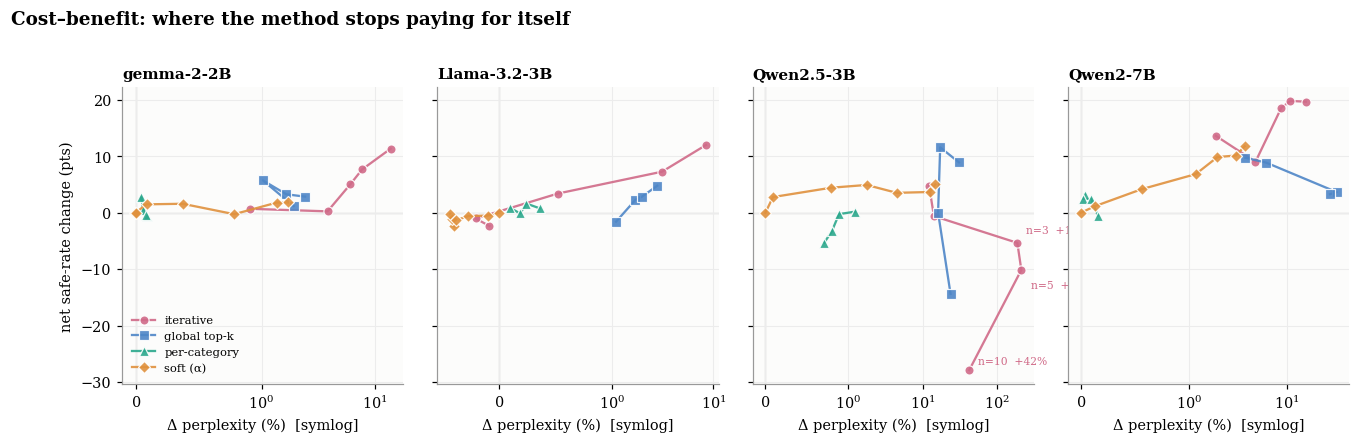

In [11]:
def fig4():
    d = runs[(runs.domain == 'general') & runs.model.isin(ALL4) & runs.d_ppl_pct.notna()]
    fig, axs = plt.subplots(1, 4, figsize=(14.4, 3.9), sharey=True)
    for ax, m in zip(axs, ALL4):
        dm = d[d.model == m]
        zeroline(ax); zeroline(ax, horizontal=False)
        for arm in ['iter', 'global', 'percat', 'soft']:
            da = dm[dm.arm == arm].sort_values('param_value')
            if da.empty:
                continue
            ax.plot(da.d_ppl_pct, da.net_pts, '-', marker=ARMm[arm], color=ARMc[arm],
                    ms=6, mec='white', mew=.8, lw=1.5, alpha=.9, label=ARMn[arm])
        ax.set_xscale('symlog', linthresh=1)
        title(ax, MODn[m]); ax.set_xlabel('Δ perplexity (%)  [symlog]')
    axs[0].set_ylabel('net safe-rate change (pts)')
    # direct labels on the blow-ups, one per point
    ax = axs[ALL4.index('Qwen2.5-3B-Instruct')]
    for pv, off in [(3.0, (6, 6)), (5.0, (6, -12)), (10.0, (6, 4))]:
        r = d[(d.model == 'Qwen2.5-3B-Instruct') & (d.arm == 'iter') & (d.param_value == pv)]
        if not r.empty:
            ax.annotate(f'n={pv:g}  +{r.d_ppl_pct.iloc[0]:.0f}%',
                        (r.d_ppl_pct.iloc[0], r.net_pts.iloc[0]), fontsize=7,
                        color=ARMc['iter'], xytext=off, textcoords='offset points')
    axs[0].legend(fontsize=7.5, loc='lower left')
    fig.suptitle('Cost–benefit: where the method stops paying for itself',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.80, wspace=.12)
    return fig

save(fig4(), 'F04_cost_benefit_pareto');

---
## Figure 5 · Does representational decoupling predict behaviour?

**Claim it supports:** no — and that is a result, not a gap.

Every general-domain config with both an HSIC reading and a safe-rate reading — 80 of them.
If HSIC decoupling were the mechanism, these clouds would have structure. They do not:
Pearson r = −0.10 on fairness and +0.11 on privacy at σ=400 (Spearman −0.41 and −0.02).
This is what licenses "the MD-Judge safe-rate is the decisive metric" as a finding rather
than a hedge. The table underneath repeats it at all four bandwidths, so the null is not a
σ artefact.

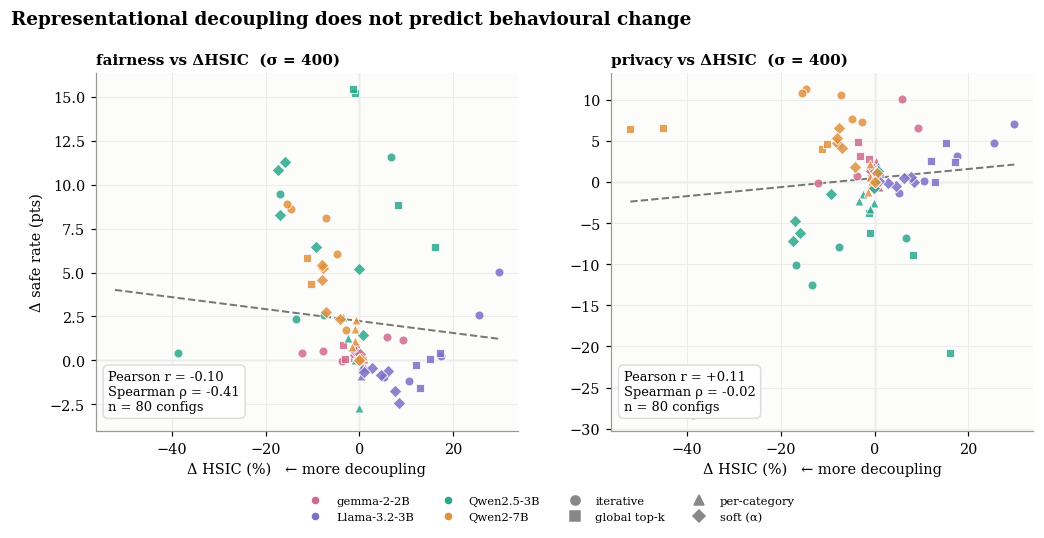

In [12]:
def fig5(sigma_col='d_hsic_s400', sigma_lab='σ = 400'):
    d = runs[(runs.domain == 'general') & runs.model.isin(ALL4) & runs[sigma_col].notna()]
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
    for ax, (axis, col) in zip(axs, [('fairness','d_fair'), ('privacy','d_priv')]):
        sub = d[d[col].notna()]
        zeroline(ax); zeroline(ax, horizontal=False)
        for m in ALL4:
            dm = sub[sub.model == m]
            for arm in ['iter','global','percat','soft']:
                da = dm[dm.arm == arm]
                if da.empty:
                    continue
                ax.scatter(da[sigma_col], pts(da[col]), color=MODc[m], marker=ARMm[arm],
                           s=34, ec='white', lw=.6, alpha=.85, zorder=3)
        x, y = sub[sigma_col].values, pts(sub[col]).values
        b, a = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 50)
        ax.plot(xr, a + b * xr, '--', color='#777', lw=1.3, zorder=2)
        r  = np.corrcoef(x, y)[0, 1]
        rs = pd.Series(x).corr(pd.Series(y), method='spearman')
        ax.text(.03, .05, f'Pearson r = {r:+.2f}\nSpearman ρ = {rs:+.2f}\nn = {len(sub)} configs',
                transform=ax.transAxes, fontsize=8.5, va='bottom',
                bbox=dict(fc='white', ec='#DDD', boxstyle='round,pad=.4'))
        title(ax, f'{axis} vs ΔHSIC  ({sigma_lab})')
        ax.set_xlabel('Δ HSIC (%)   ← more decoupling')
    axs[0].set_ylabel('Δ safe rate (pts)')
    handles  = [Line2D([], [], color=MODc[m], marker='o', ls='', mec='white', label=MODn[m])
                for m in ALL4]
    handles += [Line2D([], [], color='#888', marker=ARMm[a], ls='', label=ARMn[a])
                for a in ['iter','global','percat','soft']]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=7.5, bbox_to_anchor=(.5, -.10))
    fig.suptitle('Representational decoupling does not predict behavioural change',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.85, wspace=.22)
    return fig

save(fig5(), 'F05_hsic_vs_behaviour');

In [13]:
# the same correlation at every bandwidth — so the null result isn't a σ artefact
rows = []
for s, col in [(50,'d_hsic_s50'), (100,'d_hsic_s100'), (200,'d_hsic_s200'), (400,'d_hsic_s400')]:
    d = runs[(runs.domain == 'general') & runs[col].notna()]
    for axis, c in [('fairness','d_fair'), ('privacy','d_priv')]:
        sub = d[d[c].notna()]
        rows.append({'σ': s, 'axis': axis, 'n': len(sub),
                     'Pearson r': round(np.corrcoef(sub[col], sub[c])[0,1], 3),
                     'Spearman ρ': round(sub[col].corr(sub[c], method='spearman'), 3)})
pd.DataFrame(rows).pivot(index='σ', columns='axis', values=['Pearson r','Spearman ρ'])

Pearson r         Spearman ρ        
axis  fairness privacy   fairness privacy
σ                                        
50      -0.204   0.451     -0.401   0.172
100     -0.134   0.243     -0.421   0.025
200     -0.109   0.140     -0.417  -0.004
400     -0.105   0.112     -0.414  -0.018

---
## Figure 6 · Per-round selector dynamics

**Claim it supports:** the model whose selector never settles is the model that breaks.

This is the honest replacement for the Jaccard-churn figure. That statistic compared
*cumulative* snapshots, which forces Jaccard ≡ |Sₙ₋₁|/|Sₙ| and can detect nothing; the
per-round records can carry a real claim. `new_selected` is weights first picked at round r;
`n_fp_round` is the re-identified |N_f ∩ N_p| diagnostic.

gemma settles hardest (−45.5 % fresh picks by r10) and Qwen2-7B nearly as much (−42.3 %).
**Qwen2.5-3B barely settles at all (−7.4 %)** while its coupling diagnostic falls fastest
(−30.3 %) — less settled identification, not more.

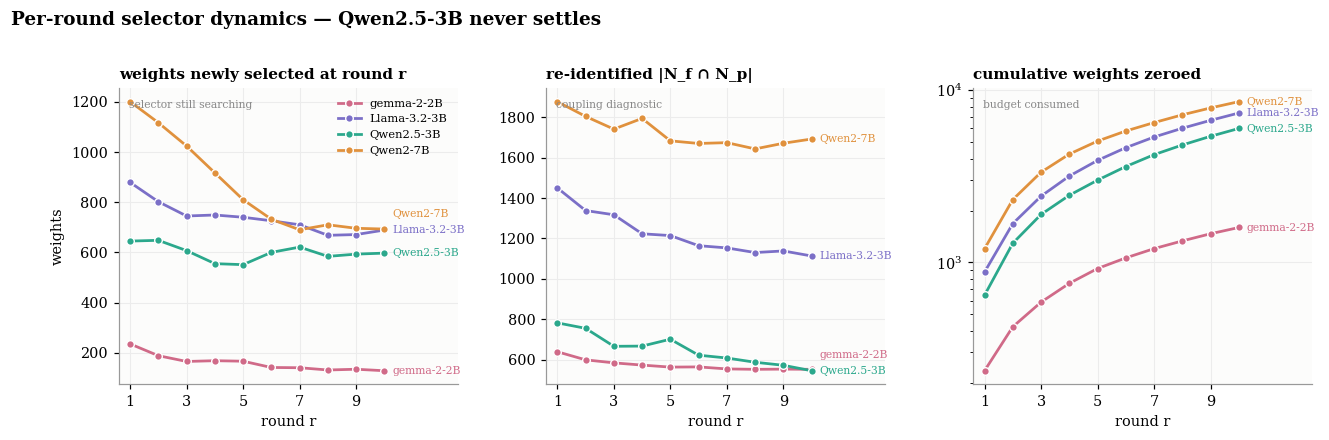

In [14]:
def fig6():
    cr = g(source='CR', domain='general')
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.9))
    panels = [('new_selected', 'weights newly selected at round r', 'selector still searching'),
              ('n_fp_round',   're-identified |N_f ∩ N_p|',          'coupling diagnostic'),
              ('cumulative_zeroed', 'cumulative weights zeroed',     'budget consumed')]
    for ax, (metric, ylab, note) in zip(axs, panels):
        ends = []
        for m in ALL4:
            d = cr[(cr.metric == metric) & (cr.model == m)].sort_values('param_value')
            if d.empty:
                continue
            ax.plot(d.param_value, d.value, '-o', color=MODc[m], ms=5, mec='white',
                    mew=.9, lw=1.8, label=MODn[m])
            ends.append((d.param_value.iloc[-1], d.value.iloc[-1], MODn[m], MODc[m]))
        title(ax, ylab); ax.set_xlabel('round r'); ax.set_xticks(range(1, 11, 2))
        ax.set_xlim(0.6, 12.6)
        label_ends(ax, ends)
        ax.text(.03, .96, note, transform=ax.transAxes, fontsize=7, color='#888', va='top')
    axs[2].set_yscale('log')
    axs[0].set_ylabel('weights')
    axs[0].legend(fontsize=7.5, loc='upper right')
    fig.suptitle('Per-round selector dynamics — Qwen2.5-3B never settles',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.80, wspace=.26)
    return fig

save(fig6(), 'F06_per_round_dynamics');

In [15]:
cr = g(source='CR')
tbl = []
for (m, dom), d in cr.groupby(['model', 'domain']):
    row = {'model': MODn.get(m, m), 'domain': dom}
    for metric, lab in [('new_selected', 'new'), ('n_fp_round', 'n_fp')]:
        s = d[d.metric == metric].set_index('param_value').value
        if len(s):
            row[f'{lab} r1'] = int(s.loc[1.0]); row[f'{lab} r10'] = int(s.loc[10.0])
            row[f'{lab} decay %'] = round((s.loc[10.0] - s.loc[1.0]) / s.loc[1.0] * 100, 1)
    tbl.append(row)
print('NB: five runs, not four — Qwen2-7B appears in both domains\n')
pd.DataFrame(tbl).set_index(['model','domain'])

NB: five runs, not four — Qwen2-7B appears in both domains



new r1  new r10  new decay %  n_fp r1  n_fp r10  \
model        domain                                                      
Llama-3.2-3B general      879      689        -21.6     1450      1113   
Qwen2-7B     clinical    1160      941        -18.9     1146       905   
             general     1201      693        -42.3     1877      1692   
Qwen2.5-3B   general      645      597         -7.4      782       545   
gemma-2-2B   general      235      128        -45.5      639       552   

                       n_fp decay %  
model        domain                  
Llama-3.2-3B general          -23.2  
Qwen2-7B     clinical         -21.0  
             general           -9.9  
Qwen2.5-3B   general          -30.3  
gemma-2-2B   general          -13.6

---
## Figure 7 · Clinical vs general transfer, same model

**Claim it supports:** the clinical domain flips the sign of the privacy effect.

Qwen2-7B only — it is the one model run in both domains. General privacy climbs to +10.8 pts;
clinical privacy is negative at **every parameter of every variant**, 30 rows without a single
exception, and significantly so at iter n=3 (−4.87 pts, p=0.004) and n=5 (−4.26, p=0.008).
Clinical fairness barely moves because it starts at 97.9 % — see Figure 8 for why.

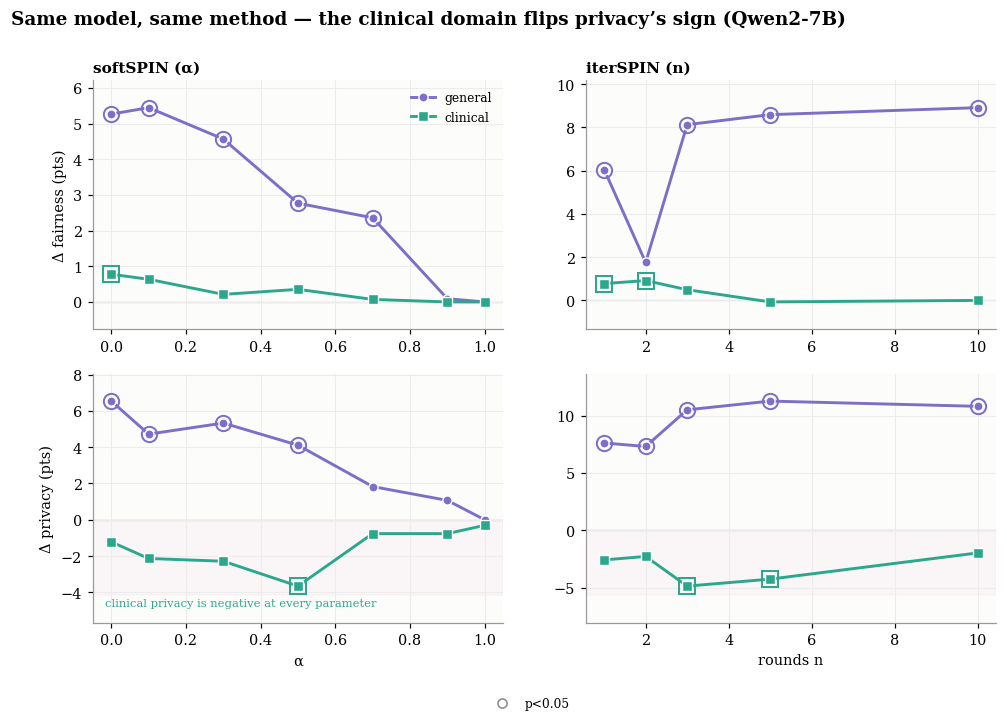

In [16]:
def fig7():
    m = 'Qwen2-7B-Instruct'
    fig, axs = plt.subplots(2, 2, figsize=(10.6, 6.4))
    for ci, (arm, xlab) in enumerate([('soft', 'α'), ('iter', 'rounds n')]):
        for ri, axis in enumerate(['fairness', 'privacy']):
            ax = axs[ri, ci]; zeroline(ax)
            for dom, c, mk in [('general', CAT[1], 'o'), ('clinical', CAT[2], 's')]:
                d = g(metric='safe_rate', model=m, domain=dom, arm=arm, axis=axis,
                      subset='pooled').sort_values('param_value')
                if d.empty:
                    continue
                ax.plot(d.param_value, pts(d.delta), '-', marker=mk, color=c, ms=6,
                        mec='white', mew=.9, lw=1.9, label=dom)
                sig = d[d.p < .05]
                ax.plot(sig.param_value, pts(sig.delta), mk, ms=10, mfc='none', mec=c,
                        mew=1.3, ls='')
            if ri == 0:
                title(ax, 'softSPIN (α)' if arm == 'soft' else 'iterSPIN (n)')
            if ci == 0:
                ax.set_ylabel(f'Δ {axis} (pts)')
            if ri == 1:
                ax.set_xlabel(xlab)
    axs[0, 0].legend(fontsize=8)
    for ax in (axs[1, 0], axs[1, 1]):
        ax.axhspan(ax.get_ylim()[0], 0, color=CAT[0], alpha=.045, zorder=0)
    axs[1, 0].text(.03, .06, 'clinical privacy is negative at every parameter',
                   transform=axs[1, 0].transAxes, fontsize=7.5, color=CAT[2],
                   ha='left', va='bottom')
    for ax in axs.ravel():
        ax.margins(y=.14)
    fig.legend(handles=[Line2D([], [], color='#888', marker='o', mfc='none', ls='',
                               label='p<0.05')],
               loc='lower center', bbox_to_anchor=(.5, -.03), fontsize=8)
    fig.suptitle('Same model, same method — the clinical domain flips privacy’s sign (Qwen2-7B)',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.88, hspace=.18, wspace=.20)
    return fig

save(fig7(), 'F07_clinical_vs_general');

In [17]:
cl = g(metric='safe_rate', domain='clinical', axis='privacy', subset='pooled')
print(f'clinical privacy deltas: {len(cl)} rows, '
      f'{(cl.delta < 0).sum()} negative, {(cl.delta >= 0).sum()} non-negative')
print(f'range: {pts(cl.delta).min():.2f} to {pts(cl.delta).max():.2f} pts')
cl[['variant','arm','param_value','value','delta','p','n']].sort_values(['variant','param_value'])

clinical privacy deltas: 13 rows, 13 negative, 0 non-negative
range: -4.87 to -0.30 pts


,variant,arm,param_value,value,delta,p,n
1053,baseline,spin,NaN,0.783866,-0.024353,0.144782,657.0
1076,iter,iter,1.0,0.782344,-0.025875,0.114468,657.0
1078,iter,iter,2.0,0.785388,-0.022831,0.175640,657.0
1072,iter,iter,3.0,0.759513,-0.048706,0.003505,657.0
1074,iter,iter,5.0,0.765601,-0.042618,0.008417,657.0
1080,iter,iter,10.0,0.788432,-0.019787,0.305243,657.0
1068,soft,soft,0.0,0.796043,-0.012177,0.475152,657.0
1058,soft,soft,0.1,0.786910,-0.021309,0.188847,657.0
1060,soft,soft,0.3,0.785388,-0.022831,0.132902,657.0
1070,soft,soft,0.5,0.771689,-0.036530,0.005583,657.0


---
## Figure 8 · Clinical fairness, decomposed by benchmark

**Claim it supports:** the pooled clinical fairness gain is one subset, diluted.

FBRT-Manual moves +8.63 pts (p = 0.004) and carries essentially the whole pooled +0.85.
Four of the seven subsets sit at exactly 100 % before the intervention and cannot move at all.
Reporting the pooled number alone would overstate the breadth of the effect considerably.

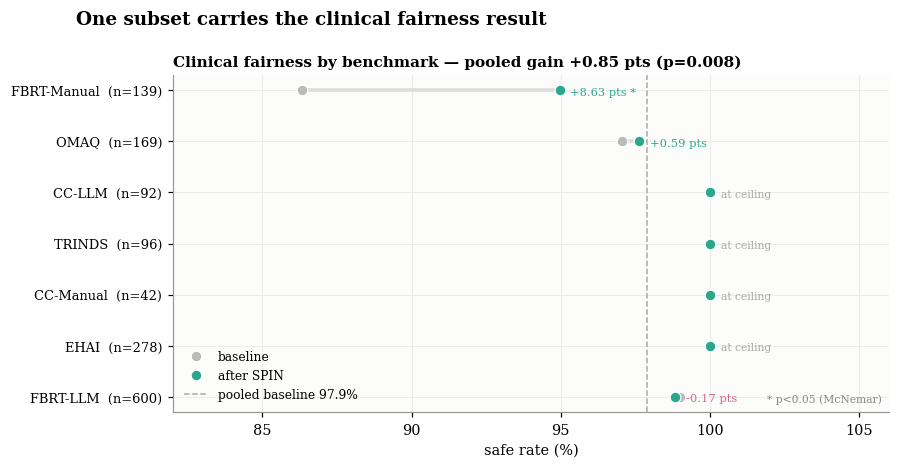

In [18]:
def fig8():
    d = g(metric='safe_rate', domain='clinical', axis='fairness', variant='baseline')
    d = d[d.subset != 'pooled'].copy()
    pooled = g(metric='safe_rate', domain='clinical', axis='fairness',
               variant='baseline', subset='pooled').iloc[0]
    d['gain'] = pts(d.delta)
    d = d.sort_values('gain')
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(8.4, 4.2))
    ax.hlines(y, d.baseline * 100, d.value * 100, color='#DDD', lw=2.4, zorder=1)
    ax.plot(d.baseline * 100, y, 'o', color='#BBB', ms=7, mec='white', mew=.8,
            label='baseline', zorder=3)
    ax.plot(d.value * 100, y, 'o', color=CAT[2], ms=7, mec='white', mew=.8,
            label='after SPIN', zorder=3)
    ax.axvline(pooled.baseline * 100, color='#AAA', ls='--', lw=1,
               label=f'pooled baseline {pooled.baseline*100:.1f}%')
    ax.set_yticks(y)
    ax.set_yticklabels([f'{s}  (n={int(n)})' for s, n in zip(d.subset, d.n)], fontsize=8.5)
    for yy, (_, r) in zip(y, d.iterrows()):
        if abs(r.gain) > .01:
            star = ' *' if r.p < .05 else ''
            ax.annotate(f'{r.gain:+.2f} pts{star}', (r.value * 100, yy), fontsize=7.5,
                        color=CAT[2] if r.gain > 0 else CAT[0],
                        xytext=(7, -3), textcoords='offset points')
        else:
            ax.annotate('at ceiling', (r.value * 100, yy), fontsize=7, color='#AAA',
                        xytext=(7, -3), textcoords='offset points')
    ax.set_xlim(82, 106); ax.set_xlabel('safe rate (%)')
    title(ax, f'Clinical fairness by benchmark — pooled gain {pts(pd.Series([pooled.delta])).iloc[0]:+.2f} pts '
              f'(p={pooled.p:.3f})')
    ax.legend(fontsize=8, loc='lower left')
    ax.text(.99, .03, '* p<0.05 (McNemar)', transform=ax.transAxes, fontsize=7,
            color='#888', ha='right')
    fig.suptitle('One subset carries the clinical fairness result',
                 x=.02, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.84)
    return fig

save(fig8(), 'F08_clinical_by_benchmark');

---
## Figure 9 · σ-robustness of the HSIC readings

**Claim it supports:** the decoupling conclusions do not depend on kernel bandwidth.

Each line is one general-domain configuration's ΔHSIC across the four RBF bandwidths.
**76 of 80 keep their sign across all four** (92 configs and 88 stable if the clinical runs are
folded in); the four that flip are all within ±0.5 % of zero, i.e. they were never claiming
anything. Magnitude grows with σ systematically, so quote a σ whenever you quote an HSIC number.

----    46
++++    30
+---     2
-+++     2


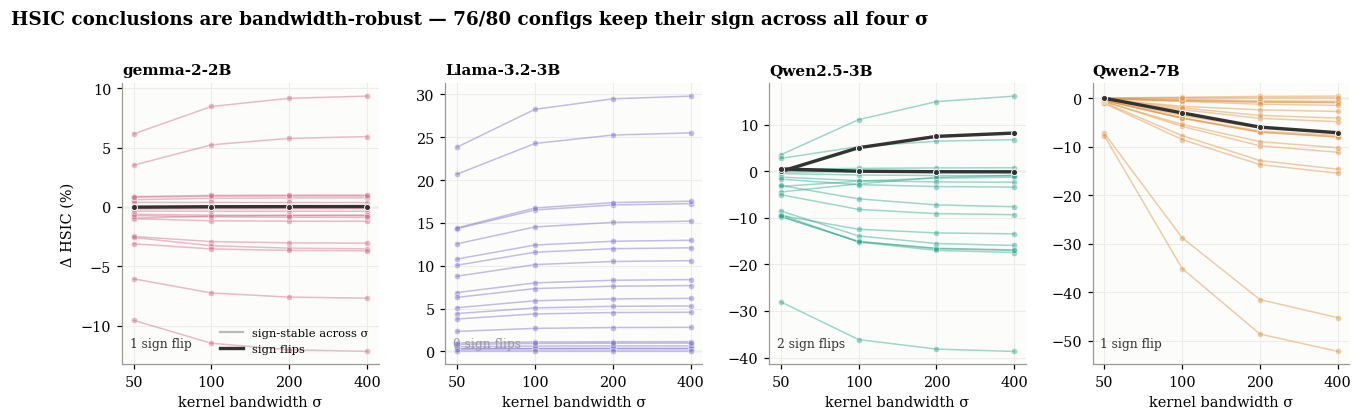

In [19]:
def fig9():
    hs = (g(metric='hsic', domain='general')
            .pivot_table(index=['variant','model','arm','param_value'],
                         columns='sigma', values='delta').dropna())
    sigmas = [50.0, 100.0, 200.0, 400.0]
    signs = hs[sigmas].apply(lambda r: ''.join('+' if v > 0 else '-' for v in r), axis=1)
    stable = signs.isin(['++++', '----'])

    fig, axs = plt.subplots(1, 4, figsize=(14.4, 3.7), sharey=False)
    for ax, m in zip(axs, ALL4):
        sub = hs[hs.index.get_level_values('model') == m]
        sg  = signs[signs.index.get_level_values('model') == m]
        zeroline(ax)
        for idx, row in sub.iterrows():
            flipped = sg.loc[idx] not in ('++++', '----')
            ax.plot(sigmas, row[sigmas].values, '-o', ms=4,
                    color='#333' if flipped else MODc[m],          # charcoal never collides
                    lw=2.2 if flipped else 1.0,                     # with a model hue
                    alpha=1.0 if flipped else .45, mec='white', mew=.6,
                    zorder=4 if flipped else 2)
        ax.set_xscale('log')
        ax.set_xticks(sigmas); ax.set_xticklabels([f'{int(v)}' for v in sigmas])
        ax.set_xticks([], minor=True)      # kill the log minor ticks that collide
        ax.tick_params(axis='x', which='minor', bottom=False)
        title(ax, MODn[m]); ax.set_xlabel('kernel bandwidth σ')
        nflip = int((~stable[stable.index.get_level_values('model') == m]).sum())
        ax.text(.03, .05, f'{nflip} sign flip' + ('' if nflip == 1 else 's'),
                transform=ax.transAxes, fontsize=8,
                color='#333' if nflip else '#999', va='bottom')
    axs[0].set_ylabel('Δ HSIC (%)')
    axs[0].legend(handles=[Line2D([], [], color='#BBB', label='sign-stable across σ'),
                           Line2D([], [], color='#333', lw=2.2, label='sign flips')],
                  fontsize=7.5, loc='lower right')
    fig.suptitle(f'HSIC conclusions are bandwidth-robust — {int(stable.sum())}/{len(stable)} '
                 'configs keep their sign across all four σ',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.80, wspace=.26)
    return fig, signs

_f9, SIGNS = fig9()
save(_f9, 'F09_sigma_robustness')
print(SIGNS.value_counts().to_string())

---
## Figure 10 · Budget-matched arm comparison

**Claim it supports:** the gains are not an artefact of how many weights were removed.

x is the actual number of weights zeroed, so the arms are compared at the budget each really
spent. `percat` matches `iter` exactly by construction; `global` is matched to within 2.5 %
(and at n=5 and n=10 it removes *slightly more* while costing far less perplexity, which runs
against the draft's own favour and so is safe to report).

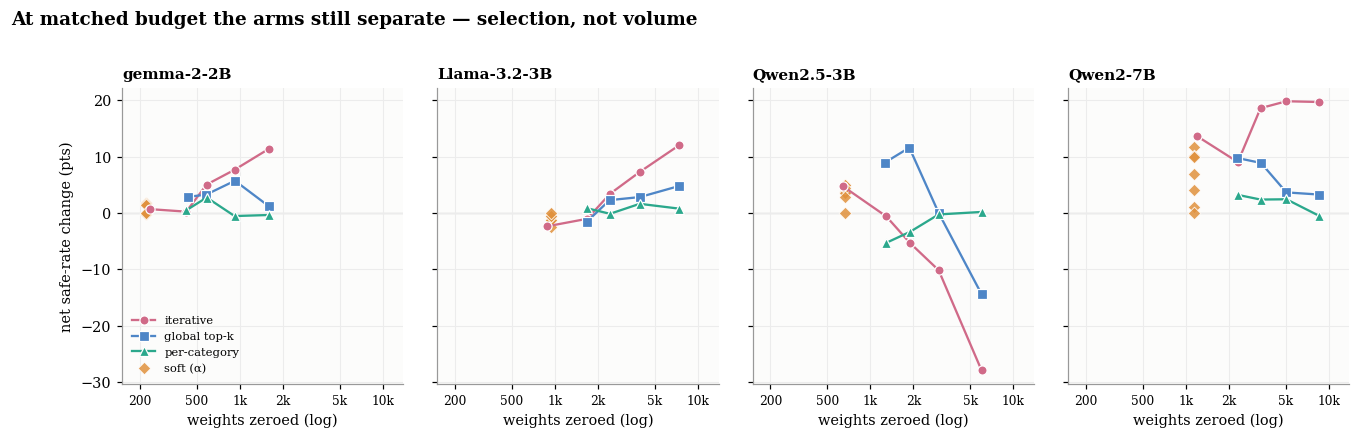

In [20]:
def fig10():
    d = runs[(runs.domain == 'general') & runs.model.isin(ALL4) & runs.zeroed.notna()
             & runs.net_pts.notna()]
    fig, axs = plt.subplots(1, 4, figsize=(14.4, 3.9), sharey=True)
    for ax, m in zip(axs, ALL4):
        dm = d[d.model == m]; zeroline(ax)
        for arm in ['iter', 'global', 'percat', 'soft']:
            da = dm[dm.arm == arm].sort_values('zeroed')
            if da.empty:
                continue
            if arm == 'soft':   # constant budget; show as a vertical band of outcomes
                ax.scatter(da.zeroed, da.net_pts, marker=ARMm[arm], color=ARMc[arm],
                           s=34, ec='white', lw=.6, alpha=.85, label=ARMn[arm])
            else:
                ax.plot(da.zeroed, da.net_pts, '-', marker=ARMm[arm], color=ARMc[arm],
                        ms=6, mec='white', mew=.8, lw=1.5, label=ARMn[arm])
        ax.set_xscale('log'); title(ax, MODn[m]); ax.set_xlabel('weights zeroed (log)')
        ax.set_xticks([200, 500, 1000, 2000, 5000, 10000])
        ax.set_xticklabels(['200', '500', '1k', '2k', '5k', '10k'], fontsize=8)
        ax.set_xticks([], minor=True)
        ax.tick_params(axis='x', which='minor', bottom=False)
        ax.set_xlim(150, 14000)
    axs[0].set_ylabel('net safe-rate change (pts)')
    axs[0].legend(fontsize=7.5, loc='lower left')
    fig.suptitle('At matched budget the arms still separate — selection, not volume',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.80, wspace=.12)
    return fig

save(fig10(), 'F10_budget_matched');

In [21]:
# how closely is the budget actually matched?
bm = (g(metric='coupled_zeroed', domain='general', variant='iter')
        .pivot_table(index=['model','param_value'], columns='arm', values='value'))
bm['global vs iter %'] = ((bm['global'] - bm['iter']) / bm['iter'] * 100).round(2)
bm['percat vs iter %'] = ((bm['percat'] - bm['iter']) / bm['iter'] * 100).round(2)
bm.round(0)

arm                                global    iter  percat  global vs iter %  \
model                 param_value                                             
Llama-3.2-3B-Instruct 1.0             NaN   879.0     NaN               NaN   
                      2.0          1662.0  1681.0  1681.0              -1.0   
                      3.0          2413.0  2426.0  2426.0              -1.0   
                      5.0          3924.0  3915.0  3915.0               0.0   
                      10.0         7380.0  7379.0  7379.0               0.0   
Qwen2-7B-Instruct     1.0             NaN  1201.0     NaN               NaN   
                      2.0          2304.0  2318.0  2318.0              -1.0   
                      3.0          3364.0  3342.0  3342.0               1.0   
                      5.0          5064.0  5069.0  5069.0              -0.0   
                      10.0         8593.0  8590.0  8590.0               0.0   
Qwen2.5-3B-Instruct   1.0             NaN   645.0     NaN               NaN   
                      2.0          1261.0  1293.0  1293.0              -2.0   
                      3.0          1875.0  1900.0  1900.0              -1.0   
                      5.0          3007.0  3006.0  3006.0               0.0   
                      10.0         6005.0  6001.0  6001.0               0.0   
gemma-2-2b-it         1.0             NaN   235.0     NaN               NaN   
                      2.0           432.0   423.0   423.0               2.0   
                      3.0           583.0   588.0   588.0              -1.0   
                      5.0           927.0   922.0   922.0               1.0   
                      10.0         1607.0  1596.0  1596.0               1.0   

arm                                percat vs iter %  
model                 param_value                    
Llama-3.2-3B-Instruct 1.0                       NaN  
                      2.0                       0.0  
                      3.0                       0.0  
                      5.0                       0.0  
                      10.0                      0.0  
Qwen2-7B-Instruct     1.0                       NaN  
                      2.0                       0.0  
                      3.0                       0.0  
                      5.0                       0.0  
                      10.0                      0.0  
Qwen2.5-3B-Instruct   1.0                       NaN  
                      2.0                       0.0  
                      3.0                       0.0  
                      5.0                       0.0  
                      10.0                      0.0  
gemma-2-2b-it         1.0                       NaN  
                      2.0                       0.0  
                      3.0                       0.0  
                      5.0                       0.0  
                      10.0                      0.0

---
## Figure 11 · Coupling specificity

**Claim it supports:** the fairness-neuron / privacy-neuron overlap is not coincidence.

### Provenance — why the general run has no |N_f| / |N_p| / |N_g|

`master_metrics.csv` carries eight `coupling_*` rows for clinical but only three for general
(`n_fp`, `n_fp_notg`, `code`). That is a gap in the source, not in the plot:

- The only files in the tree with a full `nf/np/ng` aggregate are the two **clinical**
  `coupling_stats_health.json` files (7B, and the 0.5B trial run).
- The general numbers come from the `reference_general_baseline` block *inside* that clinical
  file, which was written to hold three comparison figures and nothing else.
- The general run's own artefact (`Regular SPIN/Qwen2-7B/results/coupled_indices.json`, and the
  author-sample equivalent) records only `coupled_count` — no per-axis set sizes. Its
  `code` = 1,201 identifies it as the **author-sample** run (python-sample is 1,149).

**But those numbers are architecture, not measurement.** Selection takes `floor(p × numel)` per
weight matrix. Qwen2-7B has 28 layers × 3 MLP projections = 84 matrices, each contributing
`floor(5e-7 × 67,895,296)` = 33, so

|N_f| = |N_p| = |N_g| = 84 × 33 = **2,772**

for *any* axis in *either* domain — same model, same p. The general set sizes are therefore
identical to the clinical ones by construction, which is why nobody re-recorded them. The same
identity recovers the general chance baseline: `chance = |N_f|·|N_p| / N_params` =
1.347e-3, reproducing the clinical file's stored constant to 12 digits, and giving general
**1,393,147× chance** against clinical's 849,842×.

So the figure drops those three bars out of the domain comparison — two identical bars side by
side would imply two agreeing measurements — and states the constant once, as a constant.
Anything derived in this notebook rather than read from the CSV is drawn hatched and labelled.

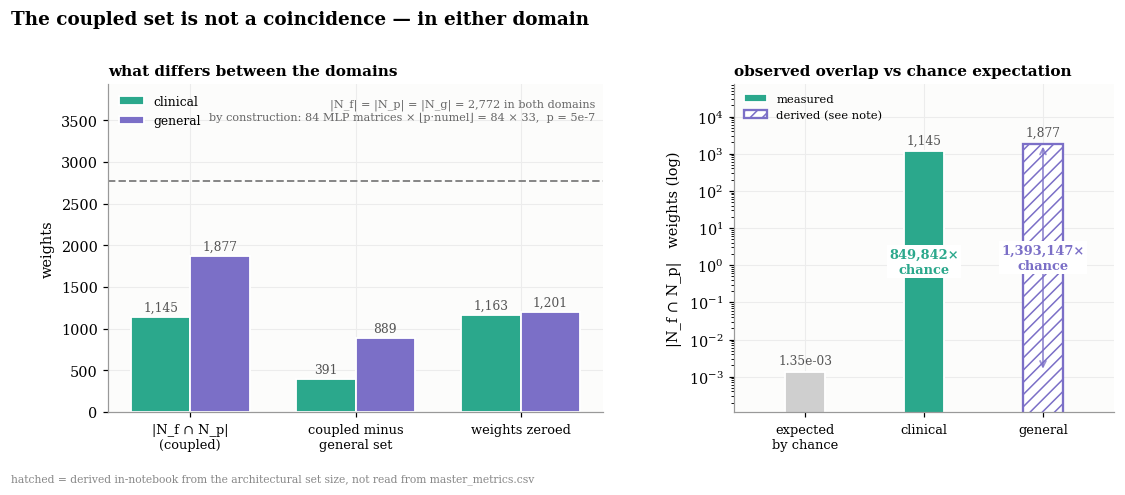

In [22]:
def fig11():
    cs = g(source='CS').set_index(['domain','metric']).value

    # architectural constant: floor(p*numel) per matrix, summed over the 84 MLP matrices.
    # Recorded for clinical only; identical for general by construction (same model, same p).
    NSET   = int(cs[('clinical','coupling_nf')])       # 2,772
    NPARAM = 5_703_204_864                              # Qwen2-7B MLP params
    chance = NSET * NSET / NPARAM
    assert abs(chance - cs[('clinical','coupling_chance_overlap')]) < 1e-12, \
        'derived chance baseline does not reproduce the stored constant'

    fig, axs = plt.subplots(1, 2, figsize=(11.8, 4.2),
                            gridspec_kw={'width_ratios': [1.3, 1]})

    # ---------------- left: only what actually differs between the domains ----------------
    ax = axs[0]
    labs = ['|N_f ∩ N_p|\n(coupled)', 'coupled minus\ngeneral set', 'weights zeroed']
    keys = ['coupling_n_fp', 'coupling_n_fp_notg', 'coupling_code']
    clin = [cs[('clinical', k)] for k in keys]
    gen  = [cs[('general',  k)] for k in keys]
    x, w = np.arange(len(labs)), .36
    ax.bar(x - w/2, clin, w, color=CAT[2], ec='white', lw=1.2, label='clinical')
    ax.bar(x + w/2, gen,  w, color=CAT[1], ec='white', lw=1.2, label='general')
    for xs, vals in [(x - w/2, clin), (x + w/2, gen)]:
        for xi, v in zip(xs, vals):
            ax.annotate(f'{v:,.0f}', (xi, v), ha='center', fontsize=8, color='#555',
                        xytext=(0, 4), textcoords='offset points')

    # the per-axis selected-set size is a constant, not a measurement — state it once
    ax.axhline(NSET, color='#888', ls='--', lw=1.3, zorder=1)
    ax.text(.985, .885, f'|N_f| = |N_p| = |N_g| = {NSET:,} in both domains\n'
                        f'by construction: 84 MLP matrices × ⌊p·numel⌋ = 84 × 33,  p = 5e-7',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7.4, color='#666')
    ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8.5)
    ax.set_ylabel('weights'); ax.set_ylim(0, NSET * 1.42)
    ax.legend(fontsize=8, loc='upper left')
    title(ax, 'what differs between the domains')

    # ---------------- right: overlap vs chance ----------------
    # NB: `chance_overlap` in the source is an EXPECTED COUNT of shared weights
    # (|N_f|·|N_p| / N_params), not a fraction — so this panel compares counts to counts.
    # Dividing an overlap *fraction* by it would understate the ratio ~2,800x.
    ax = axs[1]
    obs_c = cs[('clinical','coupling_n_fp')]
    obs_g = cs[('general', 'coupling_n_fp')]
    assert abs(obs_c / chance - cs[('clinical','coupling_ratio_vs_chance')]) < 1, \
        'count-based ratio must reproduce the stored ratio_vs_chance'
    ax.bar([0], [chance], .34, color='#CFCFCF', ec='white', lw=1.2)
    ax.bar([1], [obs_c],  .34, color=CAT[2], ec='white', lw=1.2, label='measured')
    ax.bar([2], [obs_g],  .34, color='white', ec=CAT[1], lw=1.5, hatch='///',
           label='derived (see note)')
    ax.set_yscale('log'); ax.set_xticks([0, 1, 2]); ax.set_xlim(-.6, 2.6)
    ax.set_ylim(chance / 12, max(obs_c, obs_g) * 40)
    ax.set_xticklabels(['expected\nby chance', 'clinical', 'general'], fontsize=8.5)
    ax.set_ylabel('|N_f ∩ N_p|   weights (log)')
    for xi, v in [(0, chance), (1, obs_c), (2, obs_g)]:
        ax.annotate(f'{v:.2e}' if v < 1 else f'{v:,.0f}', (xi, v), ha='center',
                    fontsize=8, color='#555', xytext=(0, 5), textcoords='offset points')
    for xi, v, c in [(1, obs_c, CAT[2]), (2, obs_g, CAT[1])]:
        ax.annotate('', xy=(xi, v), xytext=(xi, chance),
                    arrowprops=dict(arrowstyle='<->', color=c, lw=1.2, alpha=.75))
        ax.annotate(f'{v / chance:,.0f}×\nchance', xy=(xi, np.sqrt(chance * v)), ha='center',
                    va='center', fontsize=8.5, weight='bold', color=c,
                    bbox=dict(fc='white', ec='none', pad=1.5))
    ax.legend(fontsize=7.5, loc='upper left')
    title(ax, 'observed overlap vs chance expectation')

    fig.suptitle('The coupled set is not a coincidence — in either domain',
                 x=.05, ha='left', fontsize=12, weight='bold')
    fig.text(.05, -.04, 'hatched = derived in-notebook from the architectural set size, '
                        'not read from master_metrics.csv', fontsize=7, color='#888')
    fig.subplots_adjust(top=.82, wspace=.30)
    return fig

save(fig11(), 'F11_coupling_specificity');

In [23]:
# provenance, explicitly: what the CSV actually holds for each domain
cs_tbl = (g(source='CS').pivot_table(index='metric', columns='domain', values='value')
            .reindex(['coupling_nf','coupling_n_p','coupling_ng','coupling_n_fp',
                      'coupling_n_fp_notg','coupling_code','coupling_chance_overlap',
                      'coupling_ratio_vs_chance']))
cs_tbl['general'] = cs_tbl['general'].astype(object)
cs_tbl.loc[cs_tbl.general.isna(), 'general'] = '— absent from CSV —'
print('coupling_* rows in master_metrics.csv, by domain\n')
print(cs_tbl.to_string())

NSET, NPARAM = 2772, 5_703_204_864
ch = NSET * NSET / NPARAM
print('\nThe five general blanks are recoverable by construction — no re-run needed:')
print(f'  |N_f| = |N_p| = |N_g| = 84 x floor(5e-7 x 67,895,296) = 84 x 33 = {84*33:,}')
print(f'  chance_overlap        = {NSET}^2 / {NPARAM:,} = {ch:.12f}')
print(f'  ratio_vs_chance       = 1877 / chance = {1877/ch:,.0f}x   (general)')
print(f'                          1145 / chance = {1145/ch:,.0f}x   (clinical, matches stored)')

coupling_* rows in master_metrics.csv, by domain

domain                         clinical              general
metric                                                      
coupling_nf                 2772.000000  — absent from CSV —
coupling_n_p                2772.000000  — absent from CSV —
coupling_ng                 2772.000000  — absent from CSV —
coupling_n_fp               1145.000000               1877.0
coupling_n_fp_notg           391.000000                889.0
coupling_code               1163.000000               1201.0
coupling_chance_overlap        0.001347  — absent from CSV —
coupling_ratio_vs_chance  849841.640649  — absent from CSV —

The five general blanks are recoverable by construction — no re-run needed:
  |N_f| = |N_p| = |N_g| = 84 x floor(5e-7 x 67,895,296) = 84 x 33 = 2,772
  chance_overlap        = 2772^2 / 5,703,204,864 = 0.001347309834
  ratio_vs_chance       = 1877 / chance = 1,393,147x   (general)
                          1145 / chance = 849,842x   (clin

---
## Figure 12 · Two capability measures, one story (Qwen2-7B)

**Claim it supports:** perplexity is not carrying the capability argument alone.

MMLU exists in this file for Qwen2-7B general only (13 rows). `percat` is *positive* on MMLU
(+0.7 pts at n=10) while `global` is −2.7 and `iter` −2.0 — so the arm that costs no perplexity
also costs no benchmark accuracy. Separate panels, not a twin axis: the two measures have
nothing in common but their x.

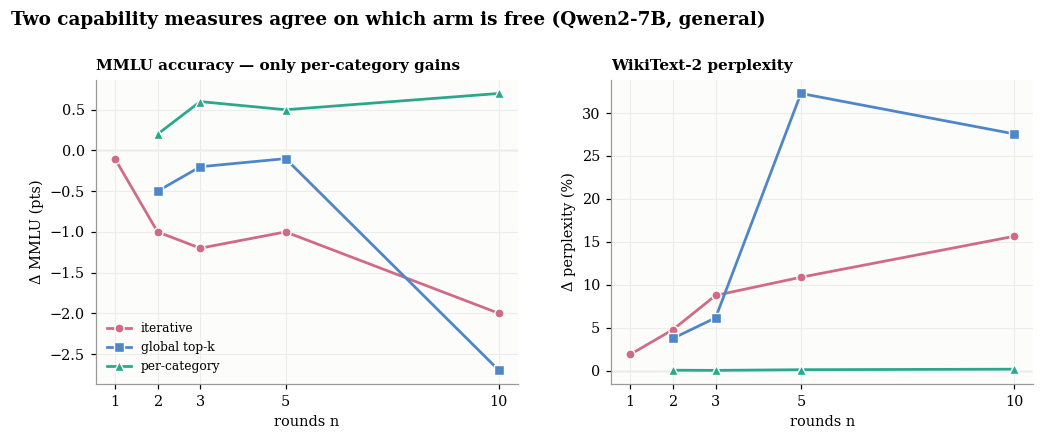

In [24]:
def fig12():
    m = 'Qwen2-7B-Instruct'
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.9))
    for arm in ['iter', 'global', 'percat']:
        d = g(metric='mmlu', model=m, domain='general', arm=arm).sort_values('param_value')
        if not d.empty:
            axs[0].plot(d.param_value, pts(d.delta), '-', marker=ARMm[arm], color=ARMc[arm],
                        ms=6, mec='white', mew=.9, lw=1.8, label=ARMn[arm])
        d = g(metric='perplexity', model=m, domain='general', arm=arm,
              subset='wikitext').sort_values('param_value')
        if not d.empty:
            axs[1].plot(d.param_value, pct(d.delta), '-', marker=ARMm[arm], color=ARMc[arm],
                        ms=6, mec='white', mew=.9, lw=1.8, label=ARMn[arm])
    for ax, lab, t in [(axs[0], 'Δ MMLU (pts)', 'MMLU accuracy — only per-category gains'),
                       (axs[1], 'Δ perplexity (%)', 'WikiText-2 perplexity')]:
        zeroline(ax); ax.set_xlabel('rounds n'); ax.set_ylabel(lab)
        ax.set_xticks([1, 2, 3, 5, 10]); title(ax, t)
    axs[0].legend(fontsize=8, loc='lower left')
    title(axs[0], 'MMLU accuracy — only per-category gains')
    fig.suptitle('Two capability measures agree on which arm is free (Qwen2-7B, general)',
                 x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.82, wspace=.22)
    return fig

save(fig12(), 'F12_mmlu_vs_perplexity');

---
## Figure 13 · What iteration costs

**Claim it supports:** the honest cost line for the method section.

Step-1 identification is the GPU-expensive stage. Per-round wall-clock is flat within a model —
it does not grow with round — so the total is simply linear in `n`. Soft-SPIN, by contrast, is
a single pass: the α sweep costs one identification run, not ten.

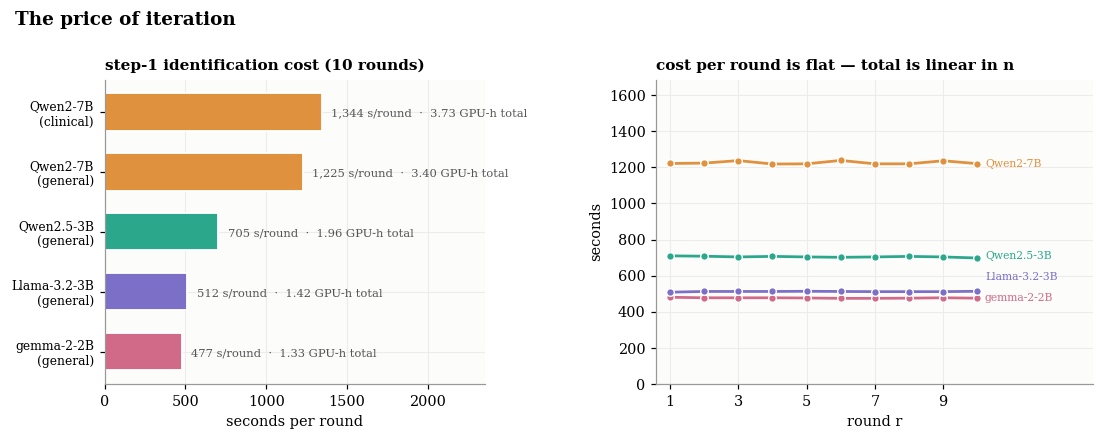

In [25]:
def fig13():
    rs = g(source='CR', metric='round_seconds')
    agg = (rs.groupby(['model','domain']).value
             .agg(['mean','sum','count']).reset_index())
    agg['hours'] = agg['sum'] / 3600
    agg['lab'] = [f"{MODn.get(m, m)}\n({d})" for m, d in zip(agg.model, agg.domain)]
    agg = agg.sort_values('mean')

    fig, axs = plt.subplots(1, 2, figsize=(11.6, 3.9),
                            gridspec_kw={'width_ratios': [1, 1.15]})
    ax = axs[0]
    cols = [MODc.get(m, '#999') for m in agg.model]
    ax.barh(np.arange(len(agg)), agg['mean'], .62, color=cols, ec='white', lw=1.2)
    ax.set_yticks(np.arange(len(agg))); ax.set_yticklabels(agg.lab, fontsize=8)
    for i, (v, h) in enumerate(zip(agg['mean'], agg['hours'])):
        ax.annotate(f'{v:,.0f} s/round  ·  {h:.2f} GPU-h total', (v, i), fontsize=7.5,
                    color='#555', xytext=(6, -3), textcoords='offset points')
    ax.set_xlim(0, agg['mean'].max() * 1.75); ax.set_xlabel('seconds per round')
    title(ax, 'step-1 identification cost (10 rounds)')

    ax = axs[1]
    ends = []
    for m in ALL4:
        d = rs[(rs.model == m) & (rs.domain == 'general')].sort_values('param_value')
        if d.empty:
            continue
        ax.plot(d.param_value, d.value, '-o', color=MODc[m], ms=5, mec='white', mew=.9,
                lw=1.8, label=MODn[m])
        ends.append((d.param_value.iloc[-1], d.value.iloc[-1], MODn[m], MODc[m]))
    ax.set_xlabel('round r'); ax.set_ylabel('seconds'); ax.set_xticks(range(1, 11, 2))
    ax.set_ylim(0, rs.value.max() * 1.25); ax.set_xlim(0.6, 13.4)
    label_ends(ax, ends, min_gap_frac=.07)
    title(ax, 'cost per round is flat — total is linear in n')
    fig.suptitle('The price of iteration', x=.055, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.82, wspace=.42)
    return fig

save(fig13(), 'F13_compute_cost');

---
## Figure 14 · Calibration-sample ablation

**Claim it supports:** the headline result is not an artefact of which calibration sample was used.

Same model, same pipeline, two different calibration samples (the SPIN authors' own vs the
python-generated one). Both give the same sign and similar magnitude on both axes; the
python sample costs slightly more perplexity and selects a slightly smaller coupled set.
Three panels because the three quantities are in three different units.

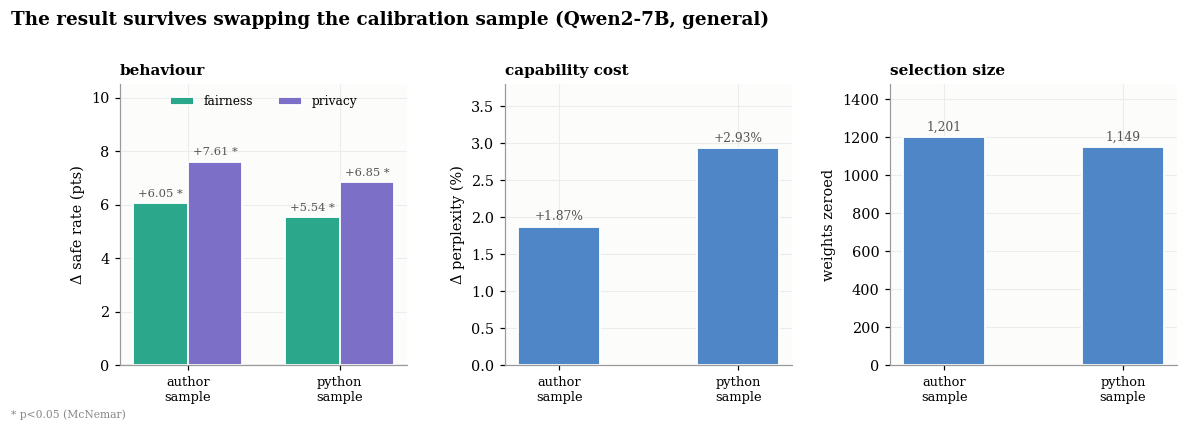

In [26]:
def fig14():
    labs = ['Qwen2-7B (author-sample)', 'Qwen2-7B (python-sample)']
    short = ['author\nsample', 'python\nsample']
    cols  = CAT[4]      # sample identity lives on the x axis; colour stays out of it
    fig, axs = plt.subplots(1, 3, figsize=(12.4, 3.7))

    ax, w = axs[0], .36
    x = np.arange(2)
    for i, (axis, c) in enumerate([('fairness', AXc['fairness']), ('privacy', AXc['privacy'])]):
        vals = [pts(g(metric='safe_rate', model=l, axis=axis, subset='pooled').delta).iloc[0]
                for l in labs]
        ps   = [g(metric='safe_rate', model=l, axis=axis, subset='pooled').p.iloc[0] for l in labs]
        ax.bar(x + (i - .5) * w, vals, w, color=c, ec='white', lw=1.2, label=axis)
        for xi, v, pv in zip(x + (i - .5) * w, vals, ps):
            ax.annotate(f'{v:+.2f}{" *" if pv < .05 else ""}', (xi, v), ha='center',
                        fontsize=7.5, color='#555', xytext=(0, 4), textcoords='offset points')
    zeroline(ax); ax.set_xticks(x); ax.set_xticklabels(short, fontsize=8.5)
    ax.set_ylabel('Δ safe rate (pts)'); ax.legend(fontsize=8, loc='upper center',
                                                  ncol=2, bbox_to_anchor=(.5, 1.0))
    title(ax, 'behaviour'); ax.set_ylim(0, 10.5)

    ax = axs[1]
    vals = [g(metric='perplexity', model=l).delta.iloc[0] for l in labs]
    ax.bar(x, vals, .46, color=cols, ec='white', lw=1.2)
    for xi, v in zip(x, vals):
        ax.annotate(f'{v:+.2f}%', (xi, v), ha='center', fontsize=8, color='#555',
                    xytext=(0, 4), textcoords='offset points')
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=8.5)
    ax.set_ylabel('Δ perplexity (%)'); title(ax, 'capability cost'); ax.set_ylim(0, 3.8)

    ax = axs[2]
    vals = [g(metric='coupled_zeroed', model=l).value.iloc[0] for l in labs]
    ax.bar(x, vals, .46, color=cols, ec='white', lw=1.2)
    for xi, v in zip(x, vals):
        ax.annotate(f'{v:,.0f}', (xi, v), ha='center', fontsize=8, color='#555',
                    xytext=(0, 4), textcoords='offset points')
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=8.5)
    ax.set_ylabel('weights zeroed'); title(ax, 'selection size'); ax.set_ylim(0, 1480)

    fig.suptitle('The result survives swapping the calibration sample (Qwen2-7B, general)',
                 x=.045, ha='left', fontsize=12, weight='bold')
    fig.text(.045, -.02, '* p<0.05 (McNemar)', fontsize=7, color='#888')
    fig.subplots_adjust(top=.80, wspace=.34)
    return fig

save(fig14(), 'F14_sample_ablation');

---
## Figure 15 · Clinical privacy — the empties-as-safe correction

**Claim it supports:** the clinical privacy result is not an artefact of how empty generations
were scored, but the correction is not free either.

`safe_rate_priv_corrected` treats empty generations as unsafe; `..._emptySafe` treats them as
safe. Both are already in **percentage points** — no ×100 here. The correction moves every
point toward zero, and at soft α=0.5 and iter n=3/n=5 the effect stays significant under both
conventions, which is the version worth reporting.

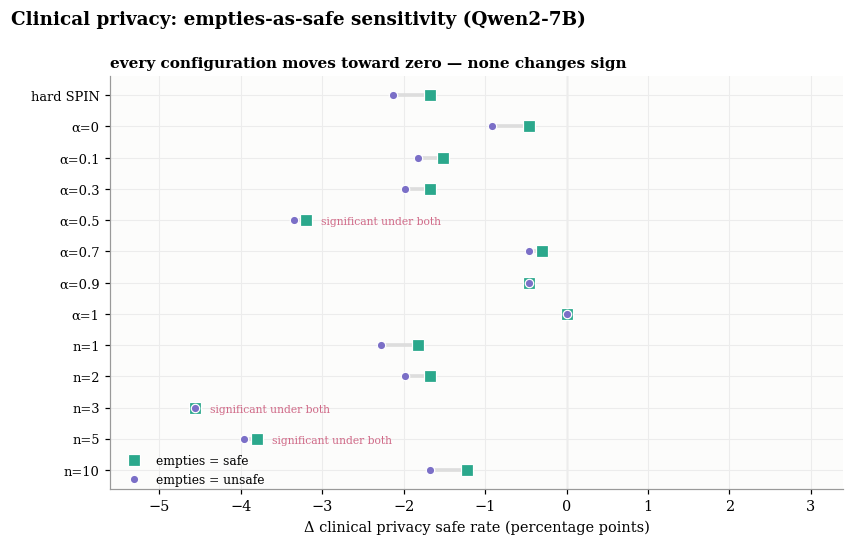

In [27]:
def fig15():
    raw  = g(metric='safe_rate_priv_corrected')
    safe = g(metric='safe_rate_priv_corrected_emptySafe')
    k = ['variant','arm','param_value']
    d = (raw.set_index(k)[['value','p']].rename(columns={'value':'v_raw','p':'p_raw'})
           .join(safe.set_index(k)[['value','p']].rename(columns={'value':'v_safe','p':'p_safe'}))
           .reset_index())
    d['lab'] = [('hard SPIN' if v == 'spin' else
                 (f'α={p:g}' if a == 'soft' else f'n={p:g}'))
                for v, a, p in zip(d.variant, d.arm, d.param_value)]
    order = (['hard SPIN']
             + [f'α={a:g}' for a in [0, .1, .3, .5, .7, .9, 1]]
             + [f'n={n:g}' for n in [1, 2, 3, 5, 10]])
    d = d.set_index('lab').reindex([o for o in order if o in set(d.lab)]).reset_index()
    y = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(8.6, 5.0))
    zeroline(ax, horizontal=False)
    ax.hlines(y, d.v_raw, d.v_safe, color='#DDD', lw=2.4, zorder=1)
    # square first, circle on top and smaller, so coincident points stay readable
    ax.plot(d.v_safe, y, 's', color=CAT[2], ms=8, mec='white', mew=.8,
            label='empties = safe', zorder=3)
    ax.plot(d.v_raw,  y, 'o', color=CAT[1], ms=5.5, mec='white', mew=.8,
            label='empties = unsafe', zorder=4)
    for yy, (_, r) in zip(y, d.iterrows()):
        if r.p_raw < .05 or r.p_safe < .05:
            both = (r.p_raw < .05) and (r.p_safe < .05)
            ax.annotate('significant under both' if both else 'significant (raw only)',
                        (max(r.v_raw, r.v_safe), yy), fontsize=7,
                        color=CAT[0] if both else '#999',
                        xytext=(10, -3), textcoords='offset points', ha='left')
    ax.set_yticks(y); ax.set_yticklabels(d.lab, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('Δ clinical privacy safe rate (percentage points)')
    ax.set_xlim(-5.6, 3.4)
    ax.legend(fontsize=8, loc='lower left', bbox_to_anchor=(0, -.02))
    title(ax, 'every configuration moves toward zero — none changes sign')
    fig.suptitle('Clinical privacy: empties-as-safe sensitivity (Qwen2-7B)',
                 x=.02, ha='left', fontsize=12, weight='bold')
    fig.subplots_adjust(top=.86)
    return fig

save(fig15(), 'F15_clinical_privacy_correction');

---
## Figure index

In [28]:
import glob
print(f'{len(_index)} figures written to {OUT}/ (pdf + png)\n')
for n in _index:
    pdf = f'{OUT}/{n}.pdf'
    print(f'  {n:38s} {os.path.getsize(pdf)/1024:6.1f} KB')

15 figures written to fig_out_master/ (pdf + png)

  F01_fairness_privacy_plane               33.3 KB
  F02_iteration_dose_response              40.0 KB
  F03_soft_alpha_dose_response             39.5 KB
  F04_cost_benefit_pareto                  34.5 KB
  F05_hsic_vs_behaviour                    44.6 KB
  F06_per_round_dynamics                   34.3 KB
  F07_clinical_vs_general                  33.2 KB
  F08_clinical_by_benchmark                32.9 KB
  F09_sigma_robustness                     58.7 KB
  F10_budget_matched                       31.9 KB
  F11_coupling_specificity                 33.6 KB
  F12_mmlu_vs_perplexity                   28.9 KB
  F13_compute_cost                         27.3 KB
  F14_sample_ablation                      28.7 KB
  F15_clinical_privacy_correction          28.6 KB
